# --- FASE 1: CONFIGURAÇÃO DO AMBIENTE ---

In [ ]:
!pip install wntr -q

In [ ]:
# --- CONEXÃO COM O DRIVE ---

import os
from google.colab import drive

# 1. Estruturação de acesso ao drive
drive.mount('/content/drive')

# 2. Define o caminho da pasta a ser utilizada
caminho_pasta = '/content/drive/MyDrive/TCC_BattLeDIM'

# 3. Modifica o diretório de trabalho do Python para a pasta definida
os.chdir(caminho_pasta)

print(f"Diretório de trabalho atual: {os.getcwd()}")

Mounted at /content/drive
Diretório de trabalho atual: /content/drive/MyDrive/TCC_BattLeDIM


In [ ]:
# --- IMPORTAÇÃO DE BIBLIOTECAS ---

# 1. Bibliotecas Padrão e de Sistema
import sys, warnings, time

# 2. Manipulação de Dados e Numérico
import pandas as pd
import numpy as np
import wntr
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# --- VERSÕES DAS BIBLIOTECAS ---

print(f"Versão do Python: {sys.version.split()[0]}")
print(f"Versão do WNTR: {wntr.__version__}")

Versão do Python: 3.12.13
Versão do WNTR: 1.4.0


## --- FASE 2: EXPLORAÇÃO DOS DADOS E CARREGAMENTO DO MODELO ---

A rede 'L-TOWN.inp' foi carregada.

--- Resumo dos Elementos da Rede ---
{'Nodes': {'Junctions': 782, 'Tanks': 1, 'Reservoirs': 2}, 'Links': {'Pipes': 905, 'Pumps': 1, 'Valves': 3}, 'Patterns': 3, 'Curves': {'Pump': 1, 'Efficiency': 0, 'Headloss': 0, 'Volume': 0}, 'Sources': 0, 'Controls': 2}


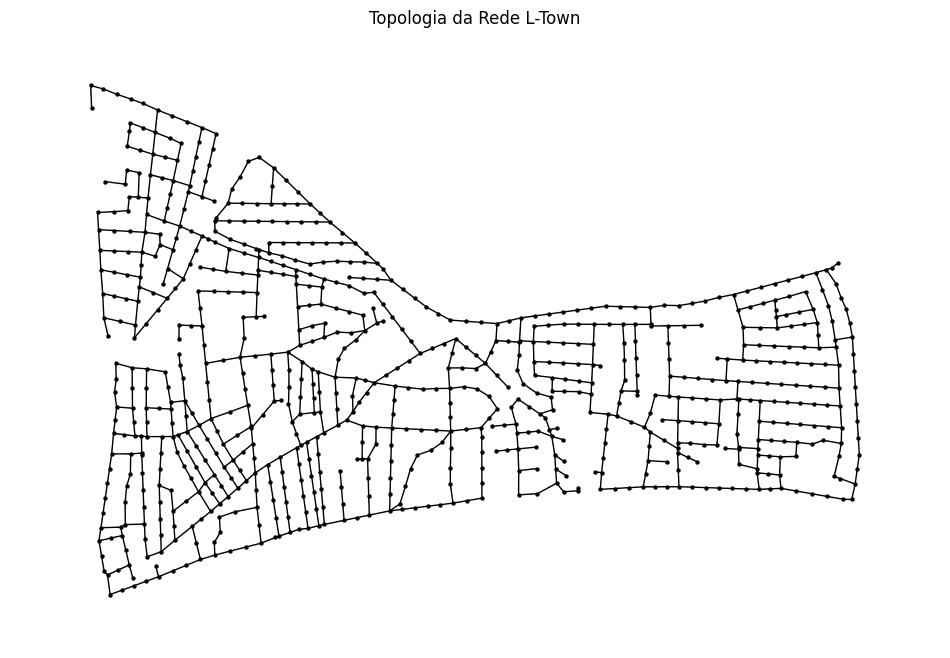

In [ ]:
# --- CARREGAMENTO DA REDE E ANÁLISE INICIAL ---

inp_filename = 'L-TOWN.inp'

try:
    wn = wntr.network.WaterNetworkModel(inp_filename)
    print(f"A rede '{inp_filename}' foi carregada.")
    print("\n--- Resumo dos Elementos da Rede ---")
    for linha in str(wn.describe(level=1)).split("\n"):
        print(linha)

except FileNotFoundError:
    print(f"ERRO: O arquivo '{inp_filename}' não foi encontrado.")
    print("Verifique se você fez o upload para o Drive ou se mudou o diretório corretamente com 'os.chdir'.")

fig, ax = plt.subplots(figsize=(12, 8))
wntr.graphics.plot_network(wn, node_size=10, link_width=1, title='Topologia da Rede L-Town', ax=ax)
plt.show()

In [ ]:
# --- CARREGAMENTO DOS DADOS DE PRESSÃO ---

pressure_file = '2018_SCADA_Pressures.csv'

try:
    df_pressure = pd.read_csv(pressure_file, index_col=0, parse_dates=True, sep=';', decimal=',')
    print("Dados de pressão carregados!")
    print(f"Dimensões do Dataset: {df_pressure.shape} (Linhas de tempo x Sensores)")
except FileNotFoundError:
    print(f"ERRO: Arquivo '{pressure_file}' não encontrado.")
    print("Verifique se o arquivo está na mesma pasta do script ou se o caminho está correto.")
except Exception as e:
    print(f"Ocorreu um erro ao ler o CSV: {e}")

print("="*30)
print("RESUMO DO PERÍODO TEMPORAL")
print("="*30)
data_inicio = df_pressure.index.min()
data_fim = df_pressure.index.max()
print(f"📅 Primeira Data (Início): {data_inicio}")
print(f"📅 Última Data (Fim):      {data_fim}")
print("="*30)

frequencia = df_pressure.index[1] - df_pressure.index[0]
print(f"Intervalo entre medições (Frequência): {frequencia}")

pontos_por_dia = 24 * 60 / (frequencia.seconds / 60)
print(f"Pontos necessários para cobrir 1 dia: {int(pontos_por_dia)}")

Dados de pressão carregados!
Dimensões do Dataset: (105120, 33) (Linhas de tempo x Sensores)
RESUMO DO PERÍODO TEMPORAL
📅 Primeira Data (Início): 2018-01-01 00:00:00
📅 Última Data (Fim):      2018-12-31 23:55:00
Intervalo entre medições (Frequência): 0 days 00:05:00
Pontos necessários para cobrir 1 dia: 288


## --- FASE 3: SIMULAÇÃO DE VAZAMENTOS NA REDE E GERAÇÃO DO DATASET SINTÉTICO ---





In [ ]:
# --- SIMULAÇÃO DE CENÁRIOS (Sem Vazamento vs. Com Vazamento) ---

inp_filename = 'L-TOWN.inp'

print(f"Carregando rede: {inp_filename}...")
wn = wntr.network.WaterNetworkModel(inp_filename)

# Configurações de Simulação
wn.options.time.duration = 48 * 3600
wn.options.time.hydraulic_timestep = 3600 # Passos de 1 hora
wn.options.time.report_timestep = 3600

print("Executando simulação BASE (sem vazamentos)... aguarde.")
sim = wntr.sim.EpanetSimulator(wn)
results_base = sim.run_sim()
print("Concluído!")

Carregando rede: L-TOWN.inp...
Executando simulação BASE (sem vazamentos)... aguarde.
Concluído!


In [ ]:
# --- IDENTIFICAÇÃO DO NÓ MAIS SENSÍVEL ---

print("Selecionando o nó mais sensível à oscilação de pressão (maior desvio padrão)...")
pressures = results_base.node['pressure'] # Armazena os resultados de pressão de cada nó na variável "pressures"
pressure_std = pressures.std() # Calcula o desvio padrão de cada nó
top_nodes = pressure_std.sort_values(ascending=False) # Ordena os nós com maiores variações
target_node = top_nodes.index[0] # Seleciona o nó com maior variação (sensibilidade em termos de variação de pressão)
print(f"Nó selecionado: {target_node}")

Selecionando o nó mais sensível à oscilação de pressão (maior desvio padrão)...
Nó selecionado: n347


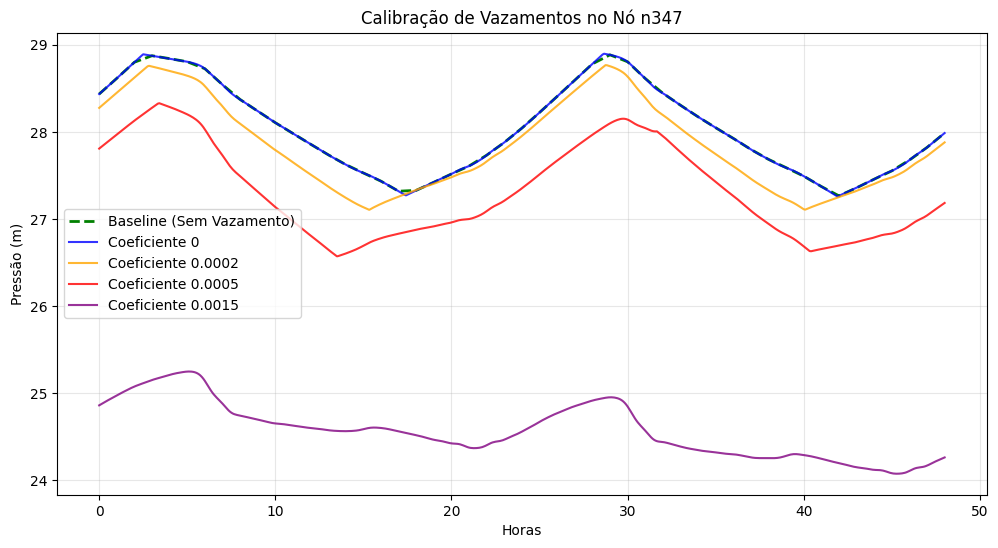

In [ ]:
# --- MAGNITUDE DOS VAZAMENTOS A SEREM SIMULADOS ---

target_node_id = target_node # Nosso nó sensível campeão
test_values = [0, 0.0002, 0.0005, 0.0015] # Valores para testar o Coeficientes de Emissor 0.0001 = Pequeno | 0.0005 = Médio | 0.00015 = Grande

plt.figure(figsize=(12, 6))
p_base = results_base.node['pressure'][target_node_id] # Baseline sem vazamentos simulado anteriormente, especificamente do nó de interesse
plt.plot(p_base.index/3600, p_base, label='Baseline (Sem Vazamento)', color='green', linewidth=2, linestyle='--') # Configura a plotagem da linha de base

colors = ['blue', 'orange', 'red', 'purple']

for i, coef in enumerate(test_values):
    # Recarregar rede limpa a cada loop
    wn_leak = wntr.network.WaterNetworkModel(inp_filename)
    wn_leak.options.time.duration = 48 * 3600
    wn_leak.options.time.hydraulic_timestep = 3600

    # Aplicar vazamento
    node = wn_leak.get_node(target_node_id)
    node.emitter_coefficient = coef

    # Simular
    sim = wntr.sim.EpanetSimulator(wn_leak)
    results_leak = sim.run_sim()
    p_leak = results_leak.node['pressure'][target_node_id]

    # Plotar
    plt.plot(p_leak.index/3600, p_leak, label=f'Coeficiente {coef}', color=colors[i], alpha=0.8)

plt.title(f'Calibração de Vazamentos no Nó {target_node_id}')
plt.ylabel('Pressão (m)')
plt.xlabel('Horas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Geração de Dados Sinéticos - Materiais RÍGIDOS/ELÁSTICO) - Geração PDA  ---

NUM_CENARIOS = 10000
inp_filename = 'L-TOWN.inp'
DURATION = 24 * 3600

# Preparação dos sensores
try:
    df_template = pd.read_csv('2018_SCADA_Pressures.csv', sep=';', decimal=',', nrows=1)
    sensor_columns = [c for c in df_template.columns if c != 'Timestamp']
except:
    wn_temp = wntr.network.WaterNetworkModel(inp_filename)
    sensor_columns = wn_temp.node_name_list

X_timeseries = []
y_data = []

failed_simulations = 0

wn_base = wntr.network.WaterNetworkModel(inp_filename)
junctions = [n for n in wn_base.node_name_list if n not in wn_base.tank_name_list and n not in wn_base.reservoir_name_list]

print(f"🏭 Gerando {NUM_CENARIOS} cenários com Mix de Materiais (Rígido/Elástico)...")

for i in tqdm(range(NUM_CENARIOS)):
    try:
        wn = wntr.network.WaterNetworkModel(inp_filename)
        wn.options.time.duration = DURATION
        wn.options.time.hydraulic_timestep = 900
        wn.options.time.report_timestep = 900

        # --- MODO PDA GLOBAL ---
        wn.options.hydraulic.demand_model = 'PDD'
        wn.options.hydraulic.minimum_pressure = 0.0
        wn.options.hydraulic.required_pressure = 20.0
        wn.options.hydraulic.pressure_exponent = 0.5 # Padrão para consumo

        # Variação estocástica da demanda global
        daily_variation = random.uniform(0.90, 1.10)
        wn.options.hydraulic.demand_multiplier = daily_variation

        # --- CONFIGURAÇÃO DO VAZAMENTO (TARGET) ---
        target_node = random.choice(junctions)
        coef = random.uniform(0.0001, 0.0015)

        node_leak = wn.get_node(target_node)
        node_leak.emitter_coefficient = coef

        # Define aleatoriamente se o cano rompido é Rígido (Metal) ou Elástico (Plástico) | Assumindo 50% de chance para cada

        if random.random() < 0.5:
            # Comportamento Rígido (Aço/Ferro Fundido/Cimento Amianto)
            node_leak.emitter_exponent = 0.5
            tipo_material = 'Rigido'
        else:
            # Comportamento Elástico (PVC/PEAD - Comum no Brasil)
            node_leak.emitter_exponent = random.uniform(1.10, 1.50)
            tipo_material = 'Elastico'

        sim = wntr.sim.EpanetSimulator(wn)
        try:
            results = sim.run_sim()
        except Exception as e:
            failed_simulations += 1
            continue

        # Extrair e Adicionar Ruído
        df_pressure = results.node['pressure'].loc[:, sensor_columns]
        series_data = df_pressure.iloc[1:97, :].values

        if series_data.shape != (96, len(sensor_columns)):
            failed_simulations += 1
            continue

        noise = np.random.normal(0, 0.2, series_data.shape)
        series_data = series_data + noise

        X_timeseries.append(series_data)
        y_data.append([target_node, coef])

    except Exception as e:
        failed_simulations += 1
        continue

X_tensor = np.array(X_timeseries)
df_y = pd.DataFrame(y_data, columns=['Leak_Node', 'Emitter_Coef'])

# --- RELATÓRIO FINAL ---
sucessos = len(X_timeseries)
taxa_sucesso = (sucessos / NUM_CENARIOS) * 100
taxa_falha = (failed_simulations / NUM_CENARIOS) * 100

print("\n" + "="*40)
print("📊 RELATÓRIO DE GERAÇÃO (MIX DE MATERIAIS)")
print("="*40)
print(f"Total Planejado:      {NUM_CENARIOS}")
print(f"✅ Cenários com Sucesso: {sucessos} ({taxa_sucesso:.1f}%)")
print(f"❌ Cenários com Falha:   {failed_simulations} ({taxa_falha:.1f}%)")
print("-" * 40)
print(f"Shape Final do Tensor:  {X_tensor.shape}")
print("="*40)

if taxa_falha > 10:
    print("⚠️ ALERTA: Taxa de falha alta. Verifique os parâmetros.")

🏭 Gerando 10000 cenários com Mix de Materiais (Rígido/Elástico)...


  0%|          | 0/10000 [00:00<?, ?it/s]


📊 RELATÓRIO DE GERAÇÃO (MIX DE MATERIAIS)
Total Planejado:      10000
✅ Cenários com Sucesso: 10000 (100.0%)
❌ Cenários com Falha:   0 (0.0%)
----------------------------------------
Shape Final do Tensor:  (10000, 96, 33)


In [ ]:
DATA_DIR = '/content/drive/MyDrive/TCC_BattLeDIM/datasets'

np.savez(
    os.path.join(DATA_DIR, 'dataset_mix_materiais_10000.npz'),
    X=X_tensor,
    y=df_y.values,
    sensors=np.array(sensor_columns)
)

print(f"Arquivo salvo em {DATA_DIR}")

Arquivo salvo em /content/drive/MyDrive/TCC_BattLeDIM/datasets
